# Testing
### Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Religion und Jahr, seit 1934.

Datum: 15.03.2022


### Importiere die notwendigen Packages

In [92]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [93]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns


In [94]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [95]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [96]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [97]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")


Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [98]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2024 3 datenstand:  1 time.struct_time(tm_year=2024, tm_mon=3, tm_mday=12, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=1, tm_yday=72, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [99]:
epoch = datetime.datetime(1960, 1, 1)

### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

**BITTE HIER ANPASSEN**

In [100]:
package_name = "bev_bestand_jahr_konfession_od3160"

In [101]:
dataset_name = "BEV316OD3160.csv"

**Statische Pfade in DWH-Dropzones**

In [102]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"

In [103]:
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"

**Statische Pfade CKAN-URLs**

In [104]:
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"

In [105]:
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [106]:
from IPython.display import Markdown as md

In [107]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_konfession_od3160 

In [108]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_konfession_od3160 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [109]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "integ"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

integ - web


In [110]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_konfession_od3160/download/BEV316OD3160.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

In [111]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


StichtagDatJahr     datetime64[ns]
Kon2AggSort_noDM             int64
Kon2AggCd_noDM               int64
Kon2AggLang_noDM            object
AnzBestWir                   int64
dtype: object

Berechne weitere Attribute falls notwendig

In [112]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.Jahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr     datetime64[ns]
Kon2AggSort_noDM             int64
Kon2AggCd_noDM               int64
Kon2AggLang_noDM            object
AnzBestWir                   int64
Jahr                datetime64[ns]
Jahr_str                    object
Jahr_nbr                     int64
dtype: object

Minimales und maximales Jahr im Datensatz

In [113]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1934 und ein Maximumjahr von 2023


### Einfache Datentests

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [114]:
#data2betested.head(6)

In [115]:
data2betested.dtypes

StichtagDatJahr     datetime64[ns]
Kon2AggSort_noDM             int64
Kon2AggCd_noDM               int64
Kon2AggLang_noDM            object
AnzBestWir                   int64
Jahr                datetime64[ns]
Jahr_str                    object
Jahr_nbr                     int64
dtype: object

In [116]:
data2betested.shape

(270, 8)

Beschreibe einzelne Attribute

In [117]:
data2betested.describe()

,Kon2AggSort_noDM,Kon2AggCd_noDM,AnzBestWir,Jahr_nbr
count,270,270,270,270
mean,2,2,128485,1978
std,1,1,71395,26
min,1,1,13634,1934
25%,1,1,91022,1956
50%,2,2,123349,1978
75%,3,3,163833,2001
max,3,3,275174,2023


Wie viele Nullwerte gibt es im Datensatz?

In [118]:
data2betested.isnull().sum()

StichtagDatJahr     0
Kon2AggSort_noDM    0
Kon2AggCd_noDM      0
Kon2AggLang_noDM    0
AnzBestWir          0
Jahr                0
Jahr_str            0
Jahr_nbr            0
dtype: int64

Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [119]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir,Jahr,Jahr_str,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [120]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()

In [121]:
data2betested.info()
data2betested.index.year.unique()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 270 entries, 1934-01-01 to 2023-01-01
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   StichtagDatJahr   270 non-null    datetime64[ns]
 1   Kon2AggSort_noDM  270 non-null    int64         
 2   Kon2AggCd_noDM    270 non-null    int64         
 3   Kon2AggLang_noDM  270 non-null    object        
 4   AnzBestWir        270 non-null    int64         
 5   Jahr_str          270 non-null    object        
 6   Jahr_nbr          270 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 16.9+ KB


Int64Index([1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947,
            1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
            1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
            1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
            1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
            2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
            2018, 2019, 2020, 2021, 2022, 2023],
           dtype='int64', name='Jahr')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [122]:
from pivottablejs import pivot_ui

#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [123]:
data2betested.loc["2022"].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir,Jahr_str,Jahr_nbr
Jahr,,,,,,,
2022-01-01,2022-01-01,2,2,Römisch-Katholisch,102074,2022-01-01,2022
2022-01-01,2022-01-01,1,1,Evangelisch-Reformiert,77107,2022-01-01,2022


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Bildungsstand

In [124]:
data2betested.columns

Index(['StichtagDatJahr', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'AnzBestWir',
       'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [138]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr','Kon2AggSort_noDM', 'Kon2AggLang_noDM']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'mean')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,Kon2AggSort_noDM,Kon2AggLang_noDM,sum_AnzBestWir
0,1934-01-01,1934,1,Evangelisch-Reformiert,208357
1,1934-01-01,1934,2,Römisch-Katholisch,92740
2,1934-01-01,1934,3,"Andere, ohne, unbekannt",14767


In [141]:
myTitle="Anteil der Wohnbevölkerung nach Religion, "+data_min_date + " - " +data_max_date

highlight = alt.selection(type='single', on='mouseover',
                          fields=['KonOGDKurz'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_AnzBestWir>0'), title=myTitle).encode(
    x=alt.X('StichtagDatJahr', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_AnzBestWir', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('Kon2AggLang_noDM', legend=alt.Legend(title="Konfession (gruppiert)", orient="right"))  
    ,tooltip=['Jahr_nbr', 'Kon2AggLang_noDM','sum_AnzBestWir']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [127]:
data2betested.columns

Index(['StichtagDatJahr', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'AnzBestWir',
       'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [128]:
myAgg.head()

sum_AnzBestWir
StichtagDatJahr Jahr_str   Kon2AggSort_noDM Kon2AggLang_noDM                       
1934-01-01      1934-01-01 1                Evangelisch-Reformiert           208357
                           2                Römisch-Katholisch                92740
                           3                Andere, ohne, unbekannt           14767
1935-01-01      1935-01-01 1                Evangelisch-Reformiert           209469
                           2                Römisch-Katholisch                93184

In [129]:
#help(sns.catplot)     

In [130]:
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")

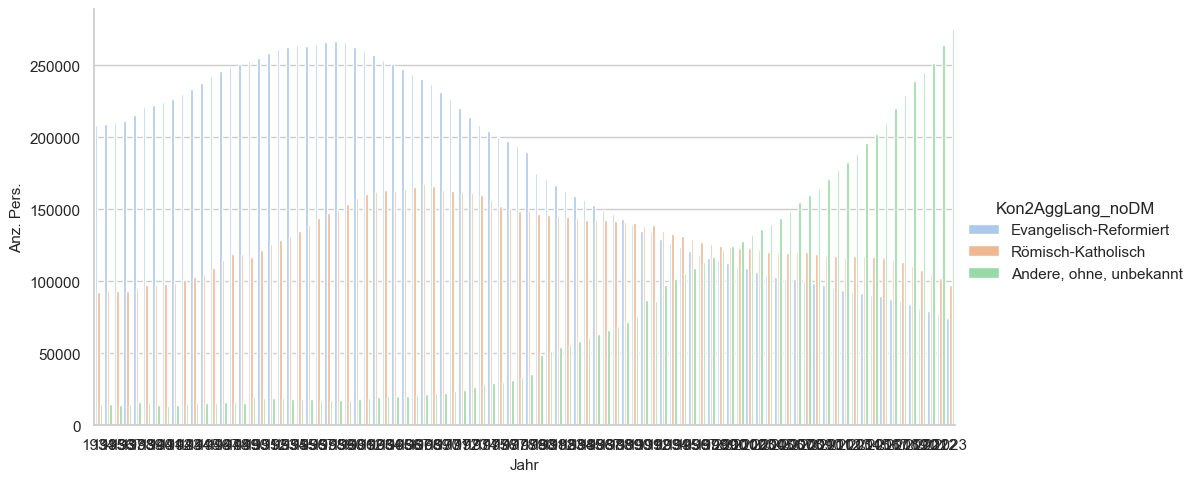

In [142]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="sum_AnzBestWir"
            , hue="Kon2AggLang_noDM"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAgg.loc[data_min_date:data_max_date].reset_index()
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


In [132]:
data2betested.columns

Index(['StichtagDatJahr', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'AnzBestWir',
       'Jahr_str', 'Jahr_nbr'],
      dtype='object')

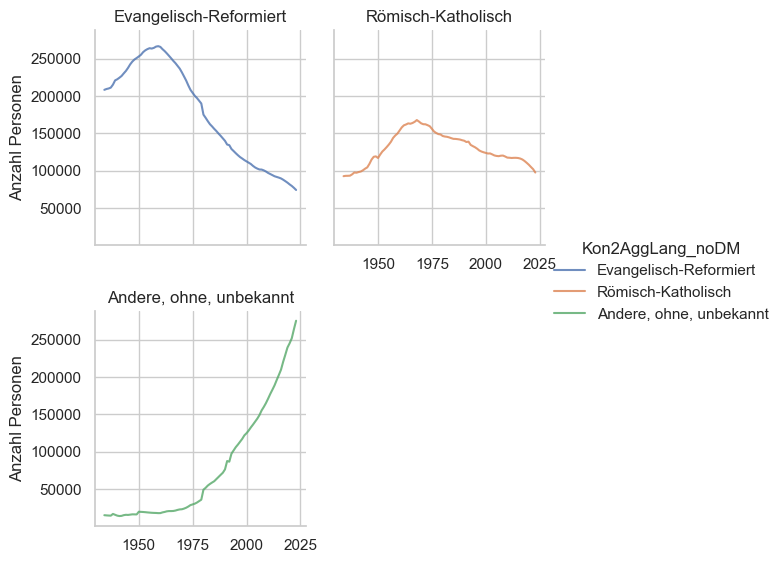

In [146]:
g2 = sns.FacetGrid(data2betested.sort_values('Kon2AggSort_noDM',ascending=True).reset_index(), col="Kon2AggLang_noDM", hue="Kon2AggLang_noDM", col_wrap=2, height=3,)
g2.map(sns.lineplot, "Jahr_nbr","AnzBestWir",alpha=.8)

g2.set_axis_labels("","Anzahl Personen")
g2.set_titles(col_template="{col_name}", row_template="{row_name}")
g2.add_legend()


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=52&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------